# PCR on vocal measurements of parkinson patients

Josef Birnöcker  
2026-05-16



# 1. Dataset description

The dataset utilized in this project is the Parkinson’s Disease Data
Set, originally created by Max Little at the University of Oxford in
collaboration with the National Centre for Voice and Speech (Denver,
Colorado). It is designed to distinguish healthy individuals from those
with Parkinson’s Disease (PD) using non-invasive voice measurements. The
dataset contains a total of 195 instances, representing sustained vowel
phonations (saying “ahhh”) from 31 individuals. Of these individuals, 23
have been diagnosed with Parkinson’s disease, and 8 are healthy control
subjects. Because there are multiple recordings per patient, the dataset
includes a name column identifying the specific patient and recording
number. Each instance is described by 24 attributes, which include a
primary identifier, a diagnosis column and 22 voice measurement
features. The voice measurement metrics contain various acoustic
properties, such as fundamental frequency, frequency variation (jitter),
amplitude variation (shimmer) and tonal noise.

# 2. Goal of the analysis

The primary objective of this analysis is to explore the dataset using
Principal Component Analysis (PCA) to identify patterns and
relationships between the acoustic features and the diagnosis status of
the patients. By reducing the dimensionality of the data, we aim to
uncover underlying structures that may differentiate healthy individuals
from those with Parkinson’s disease. Additionally, we will use a General
Linear Model (GLM) to assess the predictive power of the principal
components in classifying patients based on their diagnosis status.
Ultimately, this analysis seeks to provide insights into which acoustic
features are most relevant for distinguishing between healthy
individuals and those with Parkinson’s disease, and to evaluate the
effectiveness of these features in a predictive modeling context.



# 3. Principle component analysis

## 3.1 Data setup

In [ ]:
# import libraries
library(tidyverse)
library(mdatools)

# import dataset
park_data <- as.data.frame(read.csv('data/parkinsons.data'))

# extract the independent variable "status" and
# remove it from the dataset of dependent variables
patient_status <- park_data[, c('name','status')]
park_data$status <- NULL

# set patient ID as rowname
rownames(park_data) <- park_data$name
park_data$name <- NULL

# check for NAs
rows_with_NAs <- park_data[!complete.cases(park_data), ]
print(rows_with_NAs)

Nachdem dem Import der Daten wurde die abhängige Variable “status”
extrahiert und aus dem Datensatz der unabhängigen Variablen entfernt.
Anschließend wurde die Patienten-ID als Zeilenname festgelegt, um die
Daten besser zu organisieren. Schließlich wurde der Datensatz noch
negativ auf fehlende Werte überprüft.



## 3.2 First run (outlier identification)

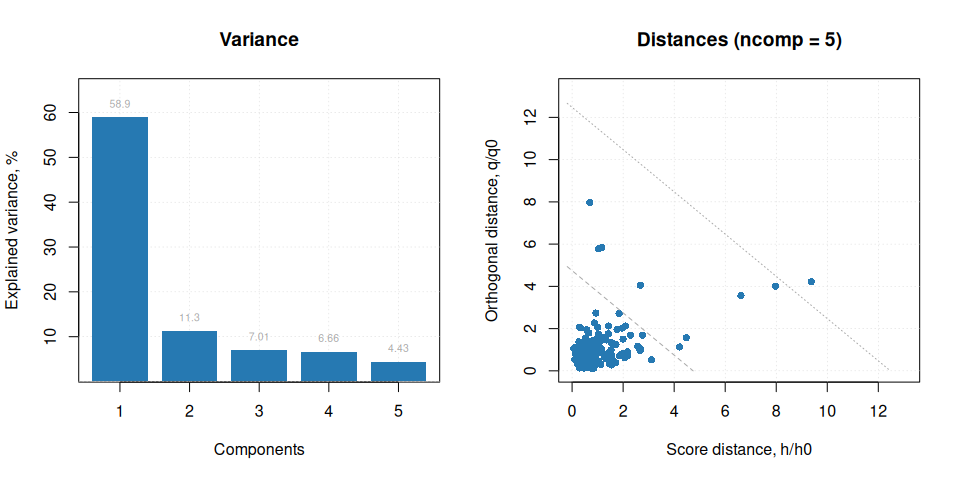

In [ ]:
# run PCA with 5 principal components
pca.park <- mdatools::pca(park_data, ncomp = 5, scale = TRUE, center=TRUE)

par(mfrow = c(1, 2))
# plot variance
plotVariance(pca.park$res$cal, type = "h", show.labels = TRUE, labels = "values")
# plot residuals
plotResiduals(pca.park, show.labels = FALSE)

In the first run of the PCA, we identified an outlier with a high
orthogonal distance in the dataset, which was the recording
“phon_R01_S35_6”. To ensure the robustness of our analysis, the outlier
was removed from the dataset. 

## 3.3 Second run (PCA with 5 components)

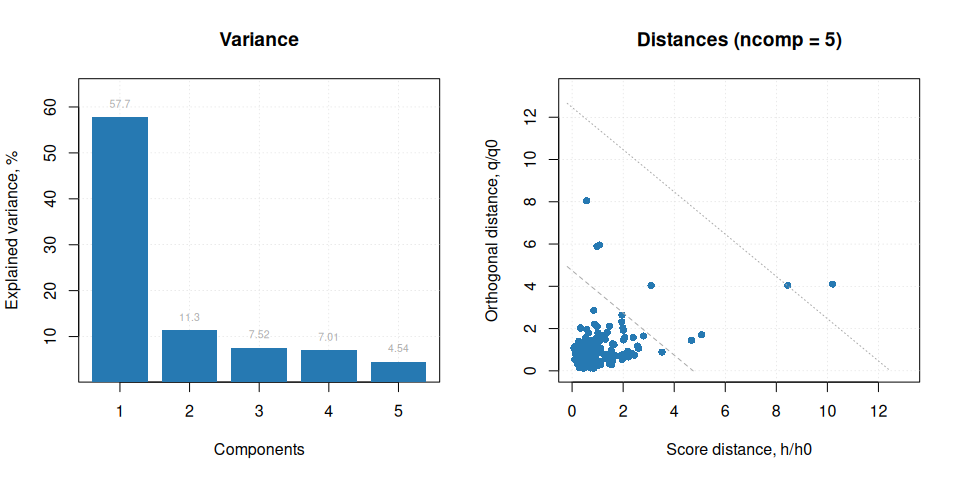

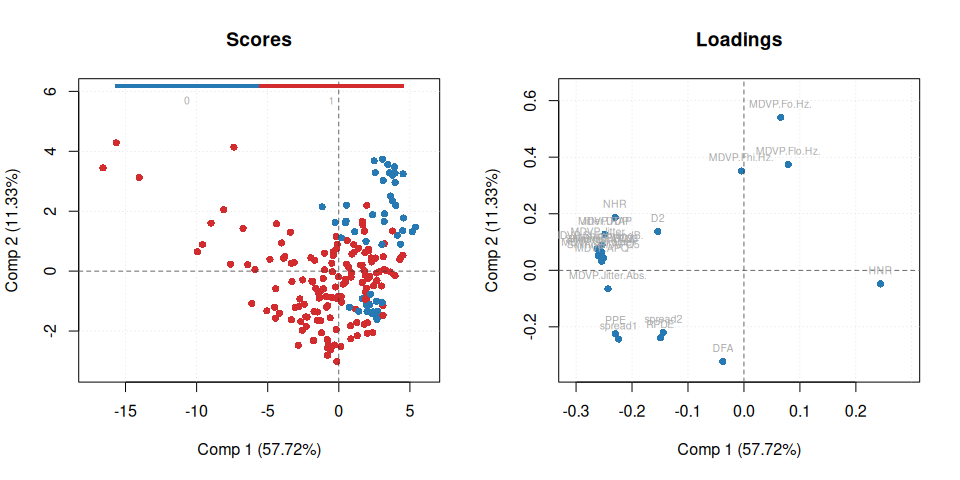

In [ ]:
# run PCA after outlier-removal
pca.park_final <- mdatools::pca(park_final, ncomp = 5, scale = TRUE, center=TRUE)

par(mfrow = c(1, 2))
# plot variance
plotVariance(pca.park_final$res$cal, type = "h", show.labels = TRUE, labels = "values")
summary(pca.park_final)

After removing the identified outlier, we reran the PCA with 5 principal
components. The variance plot indicates that the first few principal
components capture a significant portion of the variance in the data.
The residuals plot shows that there are no critical remaining outliers.

Altough the scores plot of PC1 vs PC2 does not show a clear separation
between healthy and Parkinson’s patients, the first component seems to
capture some tendencies in the data between the two groups. When looking
at the loadings plot, we can see that healthy patients tend to have
higher values in vocal fundamental frequency and the tonal measure NHR,
while Parkinson’s patients show higher values in measures of amplitude
variation (shimmer) and frequency variation (jitter). This suggests that
the first principal component may be influenced by these acoustic
features, which could be relevant for distinguishing between healthy
individuals and those with Parkinson’s disease.

# 4. General Linear Model

To further analyze the relationship between the principal components and
the diagnosis status, we performed a general linear model (GLM)
analysis. The GLM was fitted with the patients parkinsons status as the
dependent variable and the first two principal components as independent
variables. The model summary provides insights into the significance of
each component in predicting the diagnosis status, which can help us
understand how well these components differentiate between healthy
individuals and those with Parkinson’s disease.

In [ ]:
#extract PCA scores
pca.park_scores <- as.data.frame(pca.park_final$res$cal$scores)

# extract the first 2 principle components for the GLM
glm_data <- pca.park_scores %>%
  select("Comp 1","Comp 2")

# add dependent variable "status" to the df
glm_data$status <- patient_status$status

# create GLM model
glm_park <- glm(status ~ `Comp 1` + `Comp 2`, data = glm_data, family = binomial)

# model summary
summary(glm_park)

The GLM analysis revealed that both the first and second principal
components are significant predictors of the diagnosis status, with
p-values beeing massively below the 0.05 threshold. This indicates that
the acoustic features captured by these components are relevant for
distinguishing between healthy individuals and those with Parkinson’s
disease. The coefficients of the model suggest that higher values in the
two components lower the odds of a patient beeing diagnosed with
Parkinson’s disease, which is consistent with the observations from the
loadings plot where healthy patients tend to have higher values in
certain acoustic features. Overall, the GLM analysis supports the
findings from the PCA and provides a statistical basis for the observed
differences between the two groups.

Finally I accessed how well the model can predict the diagnosis status
by calculating the predicted probabilities and classifying patients
based on a threshold of 0.5. The confusion matrix showed 160 correct and
34 false predictions (10 FN and 24 FP) resulting in a accuracy of
approximately 82.5% and indicating that the model performs reasonably
well in distinguishing between healthy individuals and those with
Parkinson’s disease, although there is still room for improvement.

# 5. Conclusion

In conclusion, the PCA analysis revealed that certain acoustic features
captured by the first two principal components are relevant for
distinguishing between healthy individuals and those with Parkinson’s
disease. The GLM analysis further supported these findings by showing
that both components are significant predictors of the diagnosis status.
The model’s performance, with an accuracy of approximately 82.5%,
indicates that while it is reasonably effective in classifying patients,
there is still potential for improvement, possibly by incorporating
additional features or using more complex modeling techniques.